In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from PIL import Image

import math
import cmath

# Projeto 1 - Sinais e Sistemas em Tempo Discreto - 2023/01
# Identificação
## Nome: Leonardo Pereira Côrtes
## Matrícula: 200030582

# Questão 1

## Questão 1a (0.5 pontos)

O objetivo deste exercício é estudar a decimação e a interpolação de sinais. 
Escreva uma função em python que receba um sinal x[n] e retorne um sinal y[n] que seja a decimação por um fator de 2 do sinal de entrada x[n]. 

Em seguida, use a sua função para encontrar o sinal decimado para a entrada: 

$$ x = \left[1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0 \right]$$

In [3]:
### Código da questão 1a.
def decimacao(sinal):
    decimado =[]
    for i in range(len(sinal)):
        if i % 2 == 0:
            decimado.append(sinal[i])
    return decimado

x = [1,2,1,0,1,2,1,0,1,2,1,0,1,2,1,0,1,2,1,0]
print(f'sinal decimado: {decimacao(x)}')

sinal decimado: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## Questão 1b (0.5 pontos)

Escreva uma função em python que receba um sinal y[n] e retorne um sinal z[n] que seja a interpolação por um fator de 2 do sinal de entrada y[n]. A sua função deve aumentar o número de amostras e assinalar um novo valor para as amostras criadas. Você pode escolher se as amostras interpoladas terão o valor médio das amostras ou o valor da amostra anterior. 

Em seguida, utilize a sua função para encontrar o sinal interpolado para o sinal y[n] da questão anterior (1a).


In [4]:
### Código da questão 1b.
def interpolacao(sinal):
    interpolado = [(0.5*sinal[0]) , sinal[0]]
    for i in range(1, len(sinal)):
        interpolado.append((sinal[i-1] + sinal[i])/2) 
        interpolado.append(sinal[i]) 
    return interpolado

print(f'sinal interpolado: {interpolacao(x)}')

sinal interpolado: [0.5, 1, 1.5, 2, 1.5, 1, 0.5, 0, 0.5, 1, 1.5, 2, 1.5, 1, 0.5, 0, 0.5, 1, 1.5, 2, 1.5, 1, 0.5, 0, 0.5, 1, 1.5, 2, 1.5, 1, 0.5, 0, 0.5, 1, 1.5, 2, 1.5, 1, 0.5, 0]


## Questão 1c (1 ponto)

Uma imagem é um sinal discreto de duas dimensões. 
Escrevemos I(x,y) para representar esta imagem como uma matriz bidimensional de dimensões (w x h), onde w é a largura da imagem e h a sua altura.

Para imagens, fazemos a decimação e a interpolação separadamente, para todas as linhas e, em seguida, para todas as colunas (ou vice-versa), considerando que cada linha ou coluna é um sinal de uma dimensão.

Aplique o seu algoritmo de decimação sucessivamente até obter uma imagem com tamanho (w/16 x h/16), isto é, aplique o algoritmo 4 vezes seguidas, mostrando a imagem resultante.

Imagem original de tamanho: 512 x 512


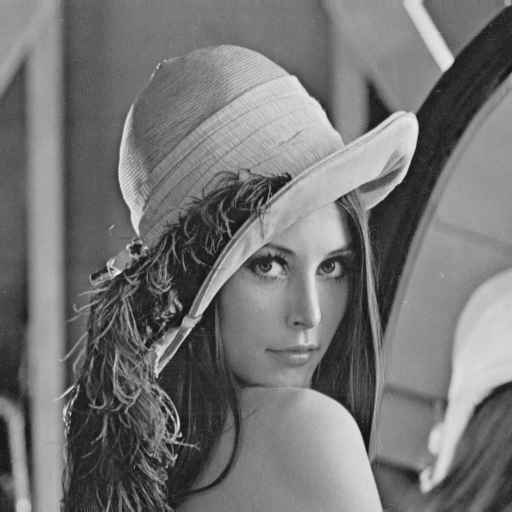

Imagem decimada de tamanho: 32 x 32


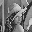

In [5]:
### Código da questão 1c.
def ate16(tamanho_original):
    return int(math.log2(tamanho_original) - math.log2(16))

im = Image.open("lena.bmp")
imagem = np.array(im)
h, w = imagem.shape
print(f'Imagem original de tamanho: {h} x {w}')
display(im)

for i in range(4):
    imagem = decimacao(imagem)
    imagem = np.transpose(imagem)
    imagem = decimacao(imagem)
    imagem = np.transpose(imagem)

imagem_decimada = Image.fromarray(imagem.astype('uint8'))
im_decimada = np.array(imagem)
hp, wp = im_decimada.shape

print(f'Imagem decimada de tamanho: {hp} x {wp}')
display(imagem_decimada)

## Questão 1d (1 ponto)

Utilizando como entrada a imagem decimada (de tamanho w/16 x h/16) da questão anterior (1c), aplique o seu algoritmo de interpolação sucessivamente até obter uma imagem com tamanho (w x h), isto é, aplique o algoritmo 4 vezes seguidas, mostrando a imagem resultante. Compare a imagem original com a imagem que foi decimada/interpolada. 

Imagem original de tamanho: 512 x 512


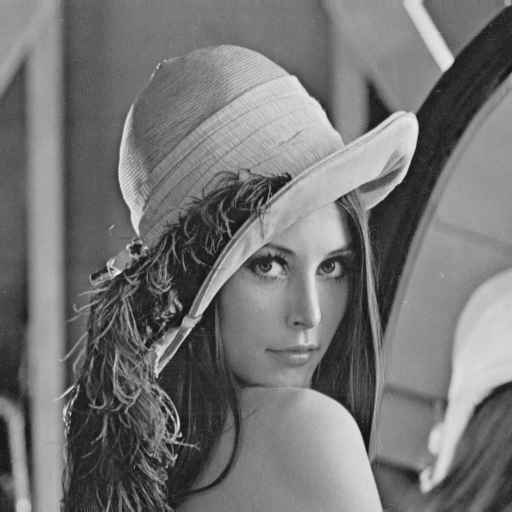

Imagem decimada de tamanho: 32 x 32


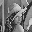

Imagem interpolada de tamanho: 512 x 512


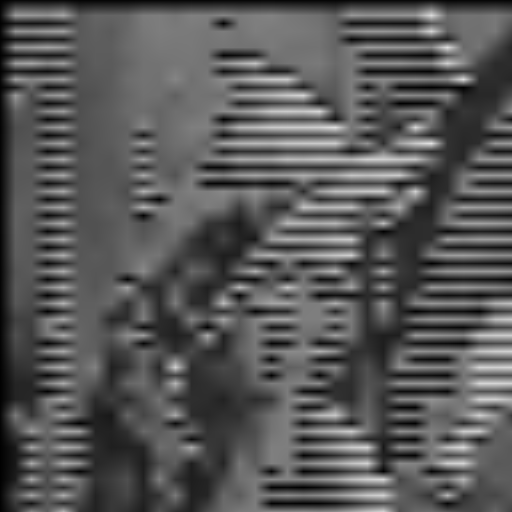

In [6]:
def ate512(tamanho_original):
    return int(math.log2(512) - math.log2(tamanho_original))

print(f'Imagem original de tamanho: {h} x {w}')
display(im)
print(f'Imagem decimada de tamanho: {hp} x {wp}')
display(imagem_decimada)
for i in range(4):
    imagem = interpolacao(imagem)
    imagem = np.transpose(imagem)
    imagem = interpolacao(imagem)
    imagem = np.transpose(imagem)

imagem_interpolada = Image.fromarray(imagem.astype('uint8'))
im_interpolada = np.array(imagem)
hp, wp = im_interpolada.shape
print(f'Imagem interpolada de tamanho: {hp} x {wp}')
display(imagem_interpolada)

# Questão 2

Considere o seguinte sistema LDIT:
$$ y\left[n+2\right] + \frac{1}{6}y\left[n\right] = x\left[n+2\right] + 2x\left[n+1\right]+x\left[n\right] $$
$$ x\left[n\right] = \left(\frac{1}{4}\right)^n u\left[n\right] $$
$$ y\left[-1\right] = y\left[-2\right] = 0 $$

## Questão 2a (1 ponto)

Determine a resposta ao impulso h[n] analiticamente. Você pode inserir a sua resposta escaneada como uma imagem abaixo.

In [1]:
### Código da questão 2a.
# y[n] + 1/6y[n-2] = x[n] + 2x[n-1] + x[n-2] 
# h[n] + 1/6h[n-2] = δ[n] + 2δ[n-1] + x[δ-2] 

# y^2 + 1/6 = 0
# Através de bhaskara encontramos as raízes complexas características = j/sqrt(6) e -j/sqrt(6) = 0 +- j*1/sqrt(6)
# Encontrando o módulo: sqrt(0^2 + 1/sqrt(6)^2) = 1/sqrt(6) => 1/sqrt(6)
# Encontrando o ângulo: como a parte real é 0 será arctg(∞) = +-π/2

# y0[n] = c1(+j/sqrt(6))^n  + c2(-j/sqrt(6))^n

# h[-1] = δ[0] + 2δ[-1] + δ[-2] - 1/6h[-2] => h[-1] = 0
# h[0] = δ[0] + 2δ[-1] + δ[-2] - 1/6h[-2] => h[0] = 1
# h[1] = δ[1] + 2δ[0] + δ[-1] - 1/6h[-1] => h[1] = 2 * 1 = 2
# h[2] = δ[2] + 2δ[1] + δ[0] - 1/6h[0] => h[2] = 1 - 1/6 * 1 = -5/6
# a partir de h[3] a entrada não influencia mais

# h[n] = bn/an * δ[n] + y0[n]u[n]
# bn/an = 1/(1/6) = 6

# h[0] = 6δ[0] + (c1(j/sqrt(6))^0  + c2(-j/sqrt(6))^0)u[0] = 6 + c1 + c2 = 1 => c1 + c2 = -5
# h[1] = 6δ[1] + (c1(j/sqrt(6))^1  + c2(-j/sqrt(6))^1)u[1] = (c1 - c2)(-j/sqrt(6)) = 2 => c1 - c2 = 2jsqrt(6)

# c1 = -5 - c2
# -5 - c2 - c2 = 2jsqrt(6) => -2c2 = 2jsqrt(6) + 5 =>  
# 
# c2 = -((-2jsqrt(6) + 5)/2)
# c1 = -5 - (-((-2jsqrt(6) + 5)/2)) = -5 + ((-2jsqrt(6) + 5)/2) = ((-2jsqrt(6) - 5)/2)

# h[n] = 6δ[n] + [-((2jsqrt(6)+5)/2)(j/sqrt(6))^n  + ((2jsqrt(6)-5)/2)(-j/sqrt(6))^n]]u[n]

## Questão 2b (1 ponto)
Escreva um código para obter a resposta ao impulso h[n] iterativamente. Compare a resposta obtida iterativamente com a resposta analítica para as primeiras 100 amostras, plotando o gráfico das duas respostas.

Calcule também o erro médio quadrático entre os dois sinais, h[n] analítico e g[n] iterativo, através da equação:

$$ MSE = \frac{1}{N} \sum_{i=0}^{N-1} \left( h\left[i\right] - g\left[i\right] \right)^2 $$

onde N é o número de amostras considerado (no caso, 100 amostras).

In [ ]:
### Código da questão 2b.

## Questão 2c (1 ponto)

Determine a resposta do sistema às condições iniciais dadas analiticamente. Você pode inserir a sua resposta escaneada como uma imagem abaixo.

In [ ]:
### Código da questão 2c.

### Questão 2d (1 ponto)
Escreva um programa para obter a resposta do sistema através da convolução da entrada com a resposta ao impulso h[n] truncada para as primeiras 20 amostras (isto é, considerando apenas as primeiras 20 amostras de h[n]).

Compare a resposta obtida pela convolução com a resposta obtida analiticamente, plotando o gráfico das duas respostas (calcule as primeiras 100 amostras do sinal). Calcule também o erro médio quadrático entre os dois sinais.

In [ ]:
### Código da questão 2d.

## Questão 2e (1 ponto)

Usando como entrada o sinal disponibilizado ('data_projeto1.mat'), determine a resposta do sistema. Plote o gráfico da entrada e da saída do sistema. 

In [ ]:
### Códgio da Questão 2e
sinal = sp.io.loadmat('data_projeto1.mat')['sinal'].ravel()

# Questão 3
Considere o seguinte sistema LDIT:
$$ y\left[n+2\right] -2~\cos \left( \frac{\pi}{8} \right) y\left[n+1\right] + y\left[n\right] = x\left[n\right] $$

## Questão 3a (1 ponto)
Determine a resposta ao impulso h[n] analiticamente. Você pode inserir a sua resposta escaneada como uma imagem abaixo.

In [ ]:
### Código da questão 3a

## Questão 3b (1 ponto)
Escreva um programa para obter a resposta ao impulso h[n] iterativamente. Compare a resposta obtida com a resposta analítica, plotando o gráfico das duas respostas para as primeiras 100 amostras. Calcule também o erro médio quadrático entre os dois sinais.

In [ ]:
### Código da questão 3b